# Mejora 11 - Corrección ortográfica y ensamble de modelos

**Proyecto - Parte 1: Machine Learning clásico**

**Estudiantes:**

[Nombre integrante 1] – [código]

[Nombre integrante 2] – [código]

**Curso:** ISIS2611 - Aprendizaje de Máquina

---

## Contexto

La Mejora 10 midió dónde están los errores de NB-LR y cuánto podían ganar, como máximo, las ideas que quedaban pendientes. Concluyó que más de la mitad del error viene de reseñas con un cierre de duda cuya etiqueta es azar respecto del texto, que el techo teórico es de 0,941 y que lo realista, con modelos que ya aciertan 93 a 98% fuera de ese grupo, son unas décimas. Este notebook implementa las dos ideas de bajo riesgo que quedaron:

1. **Corrección ortográfica.** El texto tiene errores de ortografía (letras repetidas, intercambiadas u omitidas: "semaanas", "terimne", "mjor"), y un modelo basado en palabras ve cada variante como una palabra distinta. La Mejora 10 estimó una ganancia máxima de +0,26 puntos. Se agrega un corrector basado solo en el vocabulario del propio conjunto de entrenamiento, sin diccionarios externos.
2. **Ensamble.** Se combinan, con votación suave y con apilamiento, modelos de distinto tipo (NB-LR, regresión logística por bloques, regresión logística sobre n-gramas de caracteres y el modelo en dos etapas), con y sin corrección ortográfica.

Para saber si algo mejora de verdad se usa el mismo criterio de las Mejoras 4 y 7: **las mismas 15 particiones** (3 repeticiones de validación cruzada de 5 particiones sobre las 12.000 reseñas, semillas 1, 2 y 3), comparación pareada y un mínimo de 12 de 15 particiones ganadas. Con ese criterio, el mejor modelo hasta ahora es dos etapas + NB-LR con **0,9023**.

La estructura sigue la de los notebooks anteriores:

| Paso | Sección de este notebook |
|:---|:---|
| Datos y las 15 particiones (más 15 particiones distintas solo para ajustar el corrector) | 2 |
| Preprocesamiento y modelos de las mejoras anteriores | 3 |
| Corrección ortográfica: el corrector, su auditoría y su ajuste | 4 |
| Los modelos base, con y sin corrección | 5 |
| Evaluación de los modelos base en las 15 particiones | 6 |
| Ensambles: votación suave y apilamiento | 7 |
| Diversidad y dónde se gana | 8 |
| Modelo final y predicciones para la competencia | 9 |

## Requisitos de la guía

| Requisito | Cómo se cumple |
|:---|:---|
| No usar aprendizaje profundo, transformers ni embeddings preentrenados. | No se usa ninguno. El corrector solo usa las palabras del propio conjunto de entrenamiento. |
| Usar únicamente modelos de scikit-learn. | Todos los clasificadores son de scikit-learn o clases propias que combinan `LogisticRegression` con la razón de Naive Bayes (`NBRegresionLogistica`, `ModeloDosEtapasNBLR`). El ensamble usa `VotingClassifier` y `StackingClassifier`. |
| No usar `eval.csv` para entrenar. | `eval.csv` solo se usa en la sección 9 para generar el envío. El corrector aprende su vocabulario únicamente de las reseñas de entrenamiento de cada partición. |
| Resultados replicables. | Semillas fijas, versiones en `requirements.txt` y todo el flujo en este notebook (sección 12). |

## 1. Importación de librerías

In [1]:
import os
import re
import time
import unicodedata
import warnings
from collections import Counter

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from joblib import Parallel, delayed
from scipy import sparse, stats

try:
    from nltk.stem import SnowballStemmer
except ImportError:
    %pip install nltk
    from nltk.stem import SnowballStemmer

from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import StackingClassifier, VotingClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, f1_score, precision_score,
                             recall_score, roc_auc_score)
from sklearn.model_selection import StratifiedKFold
from sklearn.multiclass import OneVsRestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, label_binarize

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 200)

RANDOM_STATE = 42
ORDEN_CLASES = ['negativo', 'neutral', 'positivo']
N_PROCESOS = 8                       # procesos en paralelo (el modelo en dos etapas usa bastante memoria)
INICIO_NOTEBOOK = time.time()

# Rutas del proyecto (este notebook está en la carpeta notebooks/)
RUTA_DATOS = os.path.join('..', 'data')
RUTA_MODELOS = os.path.join('..', 'models')
RUTA_ENVIOS = os.path.join('..', 'submissions')
os.makedirs(RUTA_MODELOS, exist_ok=True)
os.makedirs(RUTA_ENVIOS, exist_ok=True)

## 2. Datos y particiones

Se usan las 12.000 reseñas etiquetadas de `train.csv` y dos juegos de 15 particiones (3 repeticiones de validación cruzada estratificada de 5 particiones):

- **Particiones oficiales (semillas 1, 2 y 3):** son las mismas de las Mejoras 4 y 7, así que los resultados se comparan directamente con los suyos (dos etapas + NB-LR: 0,9023; NB-LR: 0,9004; modelo del notebook principal: 0,8966). Con ellas se evalúa todo.
- **Particiones de ajuste (semillas 42, 7 y 8):** se usan solo para elegir la configuración del corrector ortográfico, de modo que la evaluación oficial no participe en esa elección.

In [2]:
train = pd.read_csv(os.path.join(RUTA_DATOS, 'train.csv'))
evaluacion = pd.read_csv(os.path.join(RUTA_DATOS, 'eval.csv'))
muestra_envio = pd.read_csv(os.path.join(RUTA_DATOS, 'sample_submission.csv'))
print('train:', train.shape, '| eval:', evaluacion.shape, '| sample_submission:', muestra_envio.shape)

X = train[['text']]
y = train['label']
y_arr = y.values

SEMILLAS_OFICIALES = [1, 2, 3]       # las 15 particiones de las Mejoras 4 y 7
SEMILLAS_AJUSTE = [42, 7, 8]         # solo para ajustar el corrector


def particiones(semillas):
    lista = []
    for semilla in semillas:
        for k, (idx_ent, idx_prueba) in enumerate(StratifiedKFold(n_splits=5, shuffle=True, random_state=semilla).split(X, y)):
            lista.append({'semilla': semilla, 'k': k, 'ent': idx_ent, 'prueba': idx_prueba})
    return lista


PART_AJUSTE = particiones(SEMILLAS_AJUSTE)
PART_OFICIALES = particiones(SEMILLAS_OFICIALES)
print(f'{len(PART_OFICIALES)} particiones oficiales y {len(PART_AJUSTE)} de ajuste; cada partición entrena con {len(PART_OFICIALES[0]["ent"])} '
      f'reseñas y evalúa con {len(PART_OFICIALES[0]["prueba"])}')

train: (12000, 3) | eval: (3000, 2) | sample_submission: (3000, 2)
15 particiones oficiales y 15 de ajuste; cada partición entrena con 9600 reseñas y evalúa con 2400


## 3. Preprocesamiento y modelos de las mejoras anteriores

Se reutilizan, sin cambios, las celdas de las Mejoras 8 y 9: limpieza del texto, representación por bloques con la cláusula corregida, bolsas binarias con marcado de negación, la clase `NBRegresionLogistica` (NB-LR), el modelo en dos etapas con NB-LR (con la regresión L1 envuelta en `OneVsRestClassifier` para que funcione en scikit-learn 1.8, como en la Mejora 9) y las funciones de métricas.

In [3]:
stemmer = SnowballStemmer('spanish')
cache_raices = {}


def raiz(palabra):
    # Se guarda la raíz de cada palabra para no repetir el stemming miles de veces
    if palabra not in cache_raices:
        cache_raices[palabra] = stemmer.stem(palabra)
    return cache_raices[palabra]


def quitar_tildes(texto):
    texto = unicodedata.normalize('NFKD', texto)
    return ''.join(c for c in texto if not unicodedata.combining(c))


def limpiar_texto(texto, stop=None, stemming=True):
    texto = quitar_tildes(texto.lower())
    texto = re.sub(r'[^\w\s]', ' ', texto)
    texto = re.sub(r'\d+', ' ', texto)
    tokens = texto.split()
    if stop:
        tokens = [t for t in tokens if t not in stop]
    if stemming:
        tokens = [raiz(t) for t in tokens]
    return ' '.join(tokens)


def separar_oraciones(texto):
    return [o.strip() for o in re.split(r'(?<=[.!?])\s+', texto) if o.strip()]


# Conectores que introducen la opinión que se impone sobre la anterior
CONECTORES = r'\b(?:pero|aunque|sin embargo|aun asi|con todo|a fin de cuentas|al final)\b'


def extraer_completo(textos, stemming=True):
    return [limpiar_texto(t, stemming=stemming) for t in textos]


def extraer_ultima(textos, stemming=True):
    return [limpiar_texto(separar_oraciones(t)[-1], stemming=stemming) for t in textos]


def extraer_clausula_final(textos, stemming=True):
    salida = []
    for t in textos:
        ultima = quitar_tildes(separar_oraciones(t)[-1].lower())
        salida.append(limpiar_texto(re.split(CONECTORES, ultima)[-1], stemming=stemming))
    return salida


def bloque_tfidf(nombre, extractor, rango=(1, 2)):
    return (nombre,
            Pipeline([('extraer', FunctionTransformer(extractor)),
                      ('tfidf', TfidfVectorizer(ngram_range=rango))]),
            'text')


def construir_representacion(bloques=('completo', 'ultima', 'clausula'), rango=(1, 2)):
    extractores = {'completo': extraer_completo,
                   'ultima': extraer_ultima,
                   'clausula': extraer_clausula_final}
    return ColumnTransformer([bloque_tfidf(b, extractores[b], rango) for b in bloques])

In [4]:
# "al final de cuentas" y "a fin de cuentas" suelen ser muletillas al final de la frase, no conectores.
# Se deja de cortar ahí y, si el corte deja un fragmento de menos de 3 palabras, se toma el anterior.
CONECTORES_CORREGIDOS = r'\b(?:pero|aunque|sin embargo|aun asi|con todo|al final(?! de cuentas))\b'


def ultimo_fragmento(oracion, min_palabras=3):
    partes = [p for p in re.split(CONECTORES_CORREGIDOS, quitar_tildes(oracion.lower())) if len(p.split()) >= min_palabras]
    return partes[-1] if partes else oracion


def extraer_clausula_corregida(textos, stemming=True):
    return [limpiar_texto(ultimo_fragmento(separar_oraciones(t)[-1]), stemming=stemming) for t in textos]


def construir_representacion_corregida(rango=(1, 2)):
    return ColumnTransformer([bloque_tfidf('completo', extraer_completo, rango),
                              bloque_tfidf('ultima', extraer_ultima, rango),
                              bloque_tfidf('clausula', extraer_clausula_corregida, rango)])

In [5]:
def construir_bolsas_binarias(rango=(1, 2)):
    # Los mismos tres bloques del notebook principal, pero con presencia/ausencia de cada n-grama en lugar de TF-IDF
    extractores = {'completo': extraer_completo, 'ultima': extraer_ultima, 'clausula': extraer_clausula_corregida}
    return ColumnTransformer([
        (nombre, Pipeline([('extraer', FunctionTransformer(extractor)),
                           ('conteo', CountVectorizer(ngram_range=rango, binary=True))]), 'text')
        for nombre, extractor in extractores.items()
    ])


class NBRegresionLogistica(ClassifierMixin, BaseEstimator):
    """Regresión logística sobre atributos ponderados con la razón de Naive Bayes (NB-LR).

    Para cada clase (una contra el resto) cada atributo se multiplica por
    log(P(atributo | clase) / P(atributo | resto)), calculado con suavizado alpha como en
    MultinomialNB, y sobre esos atributos se entrena una regresión logística.
    """

    def __init__(self, C=0.3, alpha=1.0):
        self.C = C
        self.alpha = alpha

    def fit(self, X, y):
        X = sparse.csr_matrix(X, dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        self.razones_, self.modelos_ = [], []
        for clase in self.classes_:
            es_clase = y == clase
            p = self.alpha + np.asarray(X[es_clase].sum(axis=0)).ravel()
            q = self.alpha + np.asarray(X[~es_clase].sum(axis=0)).ravel()
            razon = np.log((p / p.sum()) / (q / q.sum()))
            modelo = LogisticRegression(C=self.C, max_iter=3000)
            modelo.fit(X.multiply(razon).tocsr(), es_clase.astype(int))
            self.razones_.append(razon)
            self.modelos_.append(modelo)
        return self

    def predict_proba(self, X):
        X = sparse.csr_matrix(X, dtype=float)
        P = np.column_stack([m.predict_proba(X.multiply(r).tocsr())[:, 1]
                             for m, r in zip(self.modelos_, self.razones_)])
        return P / P.sum(axis=1, keepdims=True)

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(axis=1)]


# Marcado del alcance de la negación (Mejora 5 de la rama pruebas1) sobre la cláusula corregida
NEGADORES = {'no', 'nunca', 'jamas', 'tampoco', 'ni', 'sin'}


def marcar_negacion(fragmento):
    salida = []
    for clausula in re.split(r'[.,;:!?()]+|' + CONECTORES_CORREGIDOS, fragmento):
        pieza = re.sub(r'\d+', ' ', re.sub(r'[^\w\s]', ' ', clausula))
        negando = False
        for palabra in pieza.split():
            if palabra in NEGADORES:
                negando = True
                salida.append(raiz(palabra))
                continue
            salida.append(raiz(palabra) + '_neg' if negando else raiz(palabra))
    return ' '.join(salida)


def extraer_ultima_negacion(textos):
    return [marcar_negacion(quitar_tildes(separar_oraciones(t)[-1].lower())) for t in textos]


def extraer_clausula_corregida_negacion(textos):
    return [marcar_negacion(ultimo_fragmento(separar_oraciones(t)[-1])) for t in textos]


def bolsas_binarias_negacion():
    extractores = {'completo': extraer_completo, 'ultima': extraer_ultima_negacion,
                   'clausula': extraer_clausula_corregida_negacion}
    return ColumnTransformer([
        (nombre, Pipeline([('extraer', FunctionTransformer(extractor)),
                           ('conteo', CountVectorizer(ngram_range=(1, 2), binary=True))]), 'text')
        for nombre, extractor in extractores.items()
    ])

In [6]:
K_ULTIMOS = 4          # cuántos de los últimos trozos se usan como atributos
N_INICIOS = 12         # cuántos comienzos de oración frecuentes se usan como atributos


def separar_trozos(texto):
    """Parte cada oración en trozos usando los conectores de contraste.
    Devuelve una lista de (trozo, tras_conector); tras_conector vale 1 si el trozo viene después de un conector."""
    trozos = []
    for oracion in separar_oraciones(texto):
        partes = re.split(CONECTORES_CORREGIDOS, quitar_tildes(oracion.lower()))
        for i, parte in enumerate(partes):
            if parte.strip():
                trozos.append((parte.strip(), int(i > 0)))
    return trozos


def entrenar_etapa1(textos, etiquetas, C):
    trozos, etiquetas_trozos = [], []
    for texto, etiqueta in zip(textos, etiquetas):
        for trozo, _ in separar_trozos(texto):
            trozos.append(limpiar_texto(trozo))
            etiquetas_trozos.append(etiqueta)    # cada trozo hereda la etiqueta de su reseña
    vectorizador = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
    clasificador = LogisticRegression(C=C, max_iter=2000)
    clasificador.fit(vectorizador.fit_transform(trozos), etiquetas_trozos)
    return vectorizador, clasificador


def comienzo_oracion(oracion):
    palabras = re.sub(r'[^\w\s]', '', quitar_tildes(oracion.lower())).split()
    return ' '.join(palabras[:2])


def comienzos_frecuentes(textos, n=N_INICIOS):
    conteo = Counter(comienzo_oracion(o) for t in textos for o in separar_oraciones(t)[1:])
    return [c for c, _ in conteo.most_common(n)]


class ModeloDosEtapasNBLR(ClassifierMixin, BaseEstimator):
    """Modelo en dos etapas de la Mejora 1 al que se le agregan las probabilidades de NB-LR.

    Etapa 1: puntúa cada trozo de la reseña (probabilidad de negativo, neutral y positivo).
    Etapa 2: regresión logística sobre los puntajes de los últimos trozos, las probabilidades de los
    modelos por bloques (regresión logística, Naive Bayes y NB-LR) y el comienzo de las oraciones con opinión.
    """

    def __init__(self, C_etapa1=3, C_etapa2=1, C_nblr=0.3, alpha_nblr=1.0, n_particiones=5, random_state=42):
        self.C_etapa1 = C_etapa1
        self.C_etapa2 = C_etapa2
        self.C_nblr = C_nblr
        self.alpha_nblr = alpha_nblr
        self.n_particiones = n_particiones
        self.random_state = random_state

    def _entrenar_componentes(self, textos, etiquetas):
        datos = pd.DataFrame({'text': textos.values})
        representacion = construir_representacion_corregida().fit(datos)
        matriz = representacion.transform(datos)
        # OneVsRestClassifier reproduce lo que hacía liblinear con varias clases (una regresión por clase) y sigue
        # funcionando en scikit-learn 1.8, donde liblinear ya no admite más de dos clases
        regresion = OneVsRestClassifier(LogisticRegression(C=10, penalty='l1', solver='liblinear', max_iter=3000,
                                                           random_state=RANDOM_STATE)).fit(matriz, etiquetas)
        bayes = MultinomialNB(alpha=0.3).fit(matriz, etiquetas)
        nblr = Pipeline([('rep', construir_bolsas_binarias()),
                         ('modelo', NBRegresionLogistica(C=self.C_nblr, alpha=self.alpha_nblr))]).fit(datos, etiquetas)
        vectorizador, clasificador = entrenar_etapa1(textos, etiquetas, self.C_etapa1)
        return {'representacion': representacion, 'regresion': regresion, 'bayes': bayes, 'nblr': nblr,
                'vectorizador': vectorizador, 'clasificador': clasificador}

    def _caracteristicas(self, textos, comp):
        datos = pd.DataFrame({'text': textos.values})
        matriz = comp['representacion'].transform(datos)
        prob_regresion = comp['regresion'].predict_proba(matriz)
        prob_bayes = comp['bayes'].predict_proba(matriz)
        prob_nblr = comp['nblr'].predict_proba(datos)

        trozos_por_texto = [separar_trozos(t) for t in textos]
        oraciones_por_texto = [separar_oraciones(t) for t in textos]
        probs_trozos = comp['clasificador'].predict_proba(comp['vectorizador'].transform(
            [limpiar_texto(trozo) for lista in trozos_por_texto for trozo, _ in lista]))
        probs_oraciones = comp['clasificador'].predict_proba(comp['vectorizador'].transform(
            [limpiar_texto(o) for lista in oraciones_por_texto for o in lista]))

        filas = []
        ini_t = ini_o = 0
        for k in range(len(textos)):
            trozos, oraciones = trozos_por_texto[k], oraciones_por_texto[k]
            P = probs_trozos[ini_t:ini_t + len(trozos)]
            Po = probs_oraciones[ini_o:ini_o + len(oraciones)]
            ini_t += len(trozos)
            ini_o += len(oraciones)

            fila = list(prob_regresion[k])
            for j in range(1, K_ULTIMOS + 1):
                if j <= len(trozos):
                    fila += list(P[-j]) + [trozos[-j][1]]
                else:
                    fila += [0, 0, 0, 0]
            polaridad = P[:, 2] - P[:, 0]
            con_opinion = np.where(P[:, 1] < 0.5)[0]
            fila += [polaridad[con_opinion[-1]] if len(con_opinion) > 0 else 0,
                     polaridad[con_opinion[-2]] if len(con_opinion) > 1 else 0,
                     polaridad[con_opinion[0]] if len(con_opinion) > 0 else 0,
                     len(con_opinion), P[:, 2].max(), P[:, 0].max(), P[:, 1].mean(), len(trozos)]
            fila += list(prob_bayes[k])
            oraciones_con_opinion = np.where(Po[:, 1] < 0.5)[0]
            for pos in [-1, -2]:
                comienzo = ''
                if len(oraciones_con_opinion) >= -pos:
                    comienzo = comienzo_oracion(oraciones[oraciones_con_opinion[pos]])
                fila += [int(comienzo == c) for c in self.comienzos_]
            fila += list(prob_nblr[k])
            filas.append(fila)
        return np.array(filas)

    def fit(self, X, y):
        textos = pd.Series(np.asarray(X['text']))
        etiquetas = pd.Series(np.asarray(y))
        self.classes_ = np.array(sorted(etiquetas.unique()))
        self.comienzos_ = comienzos_frecuentes(textos)

        # Atributos de la etapa 2 calculados fuera de muestra (validación cruzada interna)
        particiones = StratifiedKFold(n_splits=self.n_particiones, shuffle=True, random_state=self.random_state)
        caracteristicas = None
        for idx_ent, idx_val in particiones.split(textos, etiquetas):
            comp = self._entrenar_componentes(textos.iloc[idx_ent], etiquetas.iloc[idx_ent])
            fila_val = self._caracteristicas(textos.iloc[idx_val], comp)
            if caracteristicas is None:
                caracteristicas = np.zeros((len(textos), fila_val.shape[1]))
            caracteristicas[idx_val] = fila_val

        self.etapa2_ = Pipeline([('escala', StandardScaler()),
                                 ('modelo', LogisticRegression(C=self.C_etapa2, max_iter=3000))])
        self.etapa2_.fit(caracteristicas, etiquetas)
        self.componentes_ = self._entrenar_componentes(textos, etiquetas)
        return self

    def predict_proba(self, X):
        textos = pd.Series(np.asarray(X['text']))
        return self.etapa2_.predict_proba(self._caracteristicas(textos, self.componentes_))

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(axis=1)]

In [7]:
def metricas(y_real, prob=None, pred=None):
    """Exactitud, precisión, sensibilidad y F1 (promedio macro); AUC y AP si hay probabilidades."""
    if pred is None:
        pred = np.array(ORDEN_CLASES)[prob.argmax(axis=1)]
    fila = {'Exactitud': accuracy_score(y_real, pred),
            'Precisión': precision_score(y_real, pred, average='macro'),
            'Sensibilidad': recall_score(y_real, pred, average='macro'),
            'F1': f1_score(y_real, pred, average='macro')}
    if prob is not None:
        Y = label_binarize(y_real, classes=ORDEN_CLASES)
        fila['AUC'] = roc_auc_score(Y, prob, average='macro')
        fila['AP'] = average_precision_score(Y, prob, average='macro')
    return fila


def a_etiquetas(prob):
    return np.array(ORDEN_CLASES)[prob.argmax(axis=1)]

In [8]:
def a_etiquetas(prob):
    return np.array(ORDEN_CLASES)[np.asarray(prob).argmax(axis=1)]


def ajustar_y_predecir(modelo, X_ent, y_ent, X_prueba):
    """Entrena una copia del modelo y devuelve sus probabilidades sobre X_prueba (la tarea que se reparte entre procesos)."""
    return clone(modelo).fit(X_ent, y_ent).predict_proba(X_prueba)


def comparar_pareado(acc_a, acc_b):
    """Diferencia media (a - b) entre dos vectores de exactitudes por partición, su error estándar y en cuántas gana a."""
    d = np.asarray(acc_a) - np.asarray(acc_b)
    return {'dif_puntos': 100 * d.mean(), 'error_estandar': 100 * d.std(ddof=1) / np.sqrt(len(d)),
            'gana_en': int((d > 0).sum()), 'empata_en': int((d == 0).sum()), 'n': len(d)}

## 4. Corrección ortográfica

### 4.1 La idea

Las reseñas tienen errores de ortografía de unos pocos tipos: **letra repetida de más** ("semaanas", "intternet"), **letras intercambiadas** ("terimne", "criteiro", "auga") y **letra omitida** ("mjor", "fliz", "despus"). Como los modelos trabajan con palabras (y con su raíz, que un error cambia), cada variante mal escrita es un atributo distinto, casi siempre visto una o dos veces, que el modelo no puede aprender.

El corrector hace lo siguiente, usando **solo las reseñas de entrenamiento** de cada partición (nunca las de prueba ni `eval.csv`) y sin diccionarios externos:

1. Cuenta cuántas veces aparece cada palabra (sin tildes ni mayúsculas) y llama **conocidas** a las que aparecen 8 veces o más.
2. Una palabra es **sospechosa** si tiene al menos 4 letras y aparece menos de 3 veces.
3. Para una palabra sospechosa busca entre las conocidas las que se obtienen deshaciendo **un** error típico (quitar una letra repetida, intercambiar dos letras contiguas o agregar una letra omitida, sin agregar letras al final de la palabra). Si encuentra alguna y la más frecuente aparece al menos 3 veces más que la sospechosa, la reemplaza.

No se permiten sustituciones de una letra por otra: con ellas el corrector cambia palabras legítimas poco frecuentes ("tabla" por "talla", "hola" por "sola"), como se ve en la sección 4.3.

In [9]:
ALFABETO = 'abcdefghijklmnopqrstuvwxyz'


def ediciones_de_ortografia(w, tipo='tipicas_sin_final'):
    """Palabras que se obtienen de `w` con un solo cambio.

    'todas':             borrar, intercambiar, sustituir o insertar una letra (el corrector clásico).
    'tipicas':           solo los errores de este conjunto: letras intercambiadas, letra repetida de más y letra omitida.
    'tipicas_sin_final': igual, pero sin agregar letras al final de la palabra (evita pasar "clase" a "clases").
    """
    cortes = [(w[:i], w[i:]) for i in range(len(w) + 1)]
    intercambiadas = [a + b[1] + b[0] + b[2:] for a, b in cortes if len(b) > 1]
    if tipo == 'todas':
        borrar = [a + b[1:] for a, b in cortes if b]
        sustituir = [a + c + b[1:] for a, b in cortes if b for c in ALFABETO]
        insertar = [a + c + b for a, b in cortes for c in ALFABETO]
        return set(borrar + intercambiadas + sustituir + insertar)
    repetida = [a + b[1:] for a, b in cortes if len(b) > 1 and b[0] == b[1]]
    omitida = [a + c + b for a, b in (cortes if tipo == 'tipicas' else cortes[:-1]) for c in ALFABETO]
    return set(intercambiadas + repetida + omitida)


class CorregirOrtografia(BaseEstimator, TransformerMixin):
    """Corrige errores de ortografía con el vocabulario del texto con el que se ajusta (fit)."""

    def __init__(self, rara_si_menos_de=3, conocida_desde=8, razon=3.0, largo_min=4, ediciones='tipicas_sin_final'):
        self.rara_si_menos_de = rara_si_menos_de
        self.conocida_desde = conocida_desde
        self.razon = razon
        self.largo_min = largo_min
        self.ediciones = ediciones

    def fit(self, X, y=None):
        textos = X['text'] if hasattr(X, 'columns') else X
        self.conteo_ = Counter(quitar_tildes(w.lower()) for t in textos for w in re.findall(r'[^\W\d_]+', t))
        self.conocidas_ = {w for w, c in self.conteo_.items() if c >= self.conocida_desde}
        self.cache_ = {}
        return self

    def corregir_palabra(self, w):
        if w in self.cache_:
            return self.cache_[w]
        corregida, veces = w, self.conteo_.get(w, 0)
        if len(w) >= self.largo_min and veces < self.rara_si_menos_de:
            candidatas = [v for v in ediciones_de_ortografia(w, self.ediciones) if v in self.conocidas_]
            if candidatas:
                mejor = max(candidatas, key=lambda v: self.conteo_[v])
                if self.conteo_[mejor] >= self.razon * max(veces, 1):
                    corregida = mejor
        self.cache_[w] = corregida
        return corregida

    def transform(self, X):
        textos = X['text'] if hasattr(X, 'columns') else X

        def sustituir(m):
            w = quitar_tildes(m.group().lower())
            r = self.corregir_palabra(w)
            return r if r != w else m.group()

        return pd.DataFrame({'text': [re.sub(r'[^\W\d_]+', sustituir, t) for t in textos]})

### 4.2 Auditoría del corrector

Antes de usarlo se mira qué hace. Se ajusta con las 12.000 reseñas (solo para esta auditoría) y se cuentan las palabras que cambia, con una muestra al azar para poder revisarlas a ojo.

In [10]:
def auditar(ediciones, mostrar=45, semilla=3):
    corrector = CorregirOrtografia(ediciones=ediciones).fit(X)
    frecuencia = corrector.conteo_
    cambios = {w: corrector.corregir_palabra(w) for w in frecuencia if corrector.corregir_palabra(w) != w}
    print(f'[{ediciones}] palabras distintas: {len(frecuencia)} | sospechosas (<3 apariciones): {sum(1 for c in frecuencia.values() if c < 3)} | '
          f'palabras que se cambian: {len(cambios)} | apariciones afectadas: {sum(frecuencia[w] for w in cambios)} de {sum(frecuencia.values()):,}'.replace(',', '.'))
    muestra = np.random.default_rng(semilla).choice(sorted(cambios), size=min(mostrar, len(cambios)), replace=False)
    print('  muestra al azar:', ', '.join(f'{w} -> {cambios[w]}' for w in muestra))
    return cambios


cambios_todas = auditar('todas')
print()
cambios_elegidas = auditar('tipicas_sin_final')

[todas] palabras distintas: 5437 | sospechosas (<3 apariciones): 2815 | palabras que se cambian: 1210 | apariciones afectadas: 1430 de 646.416
  muestra al azar: unnas -> unas, revisas -> revisar, complejo -> completo, generla -> general, cajo -> caja, rmoto -> remoto, bastaante -> bastante, pasdo -> paso, danno -> dano, cotidianos -> cotidiano, detro -> dentro, habiitual -> habitual, ponga -> pongo, trata -> traia, amigos -> amigo, emblada -> embalada, revisara -> revisar, talller -> taller, guardarlas -> guardarla, lleno -> llego, comprarlos -> comprarlo, hondo -> fondo, recuerde -> recuerdo, numerro -> numero, describi -> escribi, quea -> que, compralo -> comprado, minuto -> minutos, encender -> entender, cmprando -> comprando, fabriante -> fabricante, anios -> anos, aaprato -> aparato, pesarlo -> pensarlo, movio -> movido, venga -> venia, prque -> porque, busca -> buscar, tapas -> tapa, pediido -> pedido, pasto -> paso, bolas -> bolsa, unidaddes -> unidades, snoido -> sonido, insta

[tipicas_sin_final] palabras distintas: 5437 | sospechosas (<3 apariciones): 2815 | palabras que se cambian: 697 | apariciones afectadas: 759 de 646.416
  muestra al azar: trea -> trae, resuulto -> resulto, verdaad -> verdad, foja -> floja, cale -> cable, reppisa -> repisa, bolas -> bolsa, paarar -> parar, cuuarto -> cuarto, cotiddiano -> cotidiano, diaario -> diario, furea -> fuera, poblemas -> problemas, trajinn -> trajin, anio -> animo, eleigdo -> elegido, remoo -> remoto, taia -> traia, fonod -> fondo, llaom -> llamo, compralo -> comprarlo, guadalaara -> guadalajara, rael -> real, nade -> nadie, despes -> despues, prrocesador -> procesador, comper -> compre, meediados -> mediados, ellla -> ella, cmpre -> compre, esttrella -> estrella, antreior -> anterior, aaprato -> aparato, pauge -> pague, mochla -> mochila, veniia -> venia, prebo -> pruebo, caaja -> caja, tacitl -> tactil, paquette -> paquete, panalla -> pantalla, bsatante -> bastante, undiades -> unidades, sieento -> siento, hi

**Lo que hace el corrector.** El texto tiene 5.437 palabras distintas y 2.815 de ellas aparecen menos de 3 veces. La versión elegida (errores típicos, sin letras añadidas al final) cambia 697 de esas palabras, que suman 759 apariciones de las 646.416 del texto, es decir, el 0,12% de las palabras: un cambio muy pequeño.

**La muestra al azar** muestra el comportamiento esperado: casi todo son errores de ortografía reales que se resuelven bien ("verdaad" por "verdad", "resuulto" por "resulto", "prrocesador" por "procesador", "tacitl" por "tactil", "panalla" por "pantalla", "furea" por "fuera") y algunas pocas correcciones dudosas, en las que una palabra legítima poco frecuente se cambia por otra parecida ("anio", una forma de escribir "año", por "animo"; "bolas" por "bolsa"; "foja" por "floja"). La versión que permite sustituir letras (primera muestra) hace mucho más daño: cambia 1.210 palabras, y su muestra incluye palabras legítimas como "complejo" por "completo", "ponga" por "pongo", "trata" por "traia", "lleno" por "llego", "hondo" por "fondo" o "encender" por "entender". Por eso se restringe a los tres errores típicos del conjunto.

### 4.3 Ajuste del corrector con las particiones de ajuste

Se compara NB-LR sin corrector y con varias versiones del corrector, en las 15 particiones de ajuste (semillas 42, 7 y 8, distintas de las oficiales). Es una comparación pareada: en cada partición todos los modelos se entrenan y evalúan con las mismas reseñas.

In [11]:
def nblr():
    return Pipeline([('rep', bolsas_binarias_negacion()), ('modelo', NBRegresionLogistica(C=0.1, alpha=0.5))])


def con_correccion(modelo, **parametros):
    """Pone el corrector ortográfico delante de un modelo; ambos se ajustan solo con las reseñas de entrenamiento."""
    return Pipeline([('corregir', CorregirOrtografia(**parametros)), ('modelo', modelo)])


def exactitudes_en_particiones(modelo, particiones_):
    probabilidades = Parallel(n_jobs=N_PROCESOS)(
        delayed(ajustar_y_predecir)(modelo, X.iloc[p['ent']], y.iloc[p['ent']], X.iloc[p['prueba']]) for p in particiones_)
    return np.array([(a_etiquetas(P) == y_arr[p['prueba']]).mean() for P, p in zip(probabilidades, particiones_)])


variantes = {
    'Sin corrector': nblr(),
    'Todas las ediciones (incluye sustituir letras)': con_correccion(nblr(), ediciones='todas'),
    'Solo errores típicos': con_correccion(nblr(), ediciones='tipicas'),
    'Solo errores típicos, sin letra final (elegida)': con_correccion(nblr()),
    'Elegida, sospechosa si aparece menos de 2 veces': con_correccion(nblr(), rara_si_menos_de=2),
    'Elegida, razón de frecuencia 10': con_correccion(nblr(), razon=10.0),
}
inicio = time.time()
acc_ajuste = {nombre: exactitudes_en_particiones(modelo, PART_AJUSTE) for nombre, modelo in variantes.items()}
print(f'Particiones de ajuste: {time.time() - inicio:.0f} s')

filas = []
for nombre, valores in acc_ajuste.items():
    fila = {'Variante': nombre, 'Exactitud media': valores.mean()}
    if nombre != 'Sin corrector':
        c = comparar_pareado(valores, acc_ajuste['Sin corrector'])
        fila.update({'Diferencia (puntos)': c['dif_puntos'], 'Error estándar': c['error_estandar'], 'Gana en (de 15)': c['gana_en'], 'Empata en': c['empata_en']})
    filas.append(fila)
display(pd.DataFrame(filas).set_index('Variante').round(4))

Particiones de ajuste: 118 s


,Exactitud media,Diferencia (puntos),Error estándar,Gana en (de 15),Empata en
Variante,,,,,
Sin corrector,0.8998,NaN,NaN,NaN,NaN
Todas las ediciones (incluye sustituir letras),0.9004,0.0611,0.0361,8.0,1.0
Solo errores típicos,0.9009,0.1167,0.0362,12.0,1.0
"Solo errores típicos, sin letra final (elegida)",0.9009,0.1167,0.0380,12.0,0.0
"Elegida, sospechosa si aparece menos de 2 veces",0.9009,0.1139,0.0336,11.0,2.0
"Elegida, razón de frecuencia 10",0.9009,0.1194,0.0383,12.0,0.0


Con las 15 particiones de ajuste (semillas 42, 7 y 8), NB-LR sin corrector acierta 0,8998. Las versiones del corrector que solo deshacen errores típicos ganan **+0,12 puntos** (error estándar de 0,04, unas 3 veces el error) y la versión que además permite sustituir letras gana la mitad (+0,06, solo 8 de 15 particiones), porque cambia palabras legítimas. Las cuatro variantes de errores típicos dan lo mismo entre sí (entre +0,114 y +0,119 puntos, ganando en 11 o 12 de 15 particiones), así que **no hay motivo para preferir una sobre otra**: se queda la más simple, sin letras añadidas al final y con los umbrales de la descripción (sospechosa si aparece menos de 3 veces, conocida desde 8 y razón de frecuencia de 3). Esta elección se hizo con particiones distintas a las oficiales.

## 5. Los modelos base, con y sin corrección ortográfica

Para el ensamble se necesitan modelos que se equivoquen en reseñas distintas. Se usan cuatro tipos, cada uno con y sin corrección ortográfica (8 modelos en total):

| Modelo | Qué es | Origen |
|:---|:---|:---|
| **NB-LR** | Tres regresiones logísticas sobre bolsas binarias con negación, ponderadas con la razón de Naive Bayes | Mejora 7 |
| **Regresión logística por bloques** | Regresión logística L1 sobre TF-IDF de texto completo, última oración y cláusula final | Notebook principal |
| **Regresión logística por caracteres** | Regresión logística sobre TF-IDF de n-gramas de 3 a 5 caracteres (texto completo y cláusula final), sin quitar la terminación de las palabras. Es la más tolerante a errores de ortografía y la más distinta de las demás | Nueva (`C = 10`, fijado sin ajustar) |
| **Dos etapas + NB-LR** | Puntúa cada trozo de la reseña y una segunda regresión decide con esos puntajes | Mejoras 1 y 7 |

In [12]:
def completo_sin_raiz(textos):
    return [limpiar_texto(t, stemming=False) for t in textos]


def clausula_sin_raiz(textos):
    return [limpiar_texto(ultimo_fragmento(separar_oraciones(t)[-1]), stemming=False) for t in textos]


def representacion_caracteres():
    return ColumnTransformer([
        ('c_completo', Pipeline([('extraer', FunctionTransformer(completo_sin_raiz)),
                                 ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=3, sublinear_tf=True))]), 'text'),
        ('c_clausula', Pipeline([('extraer', FunctionTransformer(clausula_sin_raiz)),
                                 ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=3, sublinear_tf=True))]), 'text')])


def regresion_por_bloques():
    return Pipeline([('rep', construir_representacion_corregida()),
                     ('modelo', OneVsRestClassifier(LogisticRegression(C=10, penalty='l1', solver='liblinear', max_iter=3000, random_state=RANDOM_STATE)))])


def regresion_por_caracteres():
    return Pipeline([('rep', representacion_caracteres()),
                     ('modelo', OneVsRestClassifier(LogisticRegression(C=10, solver='liblinear', max_iter=3000)))])


TIPOS = {'NB-LR': nblr, 'Regresión logística por bloques': regresion_por_bloques,
         'Regresión logística por caracteres': regresion_por_caracteres,
         'Dos etapas + NB-LR': lambda: ModeloDosEtapasNBLR(C_etapa2=0.1)}
SUFIJO = ' + ortografía'
BASE = {}
for nombre, fabrica in TIPOS.items():
    BASE[nombre] = fabrica()
    BASE[nombre + SUFIJO] = con_correccion(fabrica())
SIN_ORTOGRAFIA = list(TIPOS)
CON_ORTOGRAFIA = [n + SUFIJO for n in TIPOS]
print('Modelos base:', list(BASE))

Modelos base: ['NB-LR', 'NB-LR + ortografía', 'Regresión logística por bloques', 'Regresión logística por bloques + ortografía', 'Regresión logística por caracteres', 'Regresión logística por caracteres + ortografía', 'Dos etapas + NB-LR', 'Dos etapas + NB-LR + ortografía']


## 6. Evaluación de los modelos base en las 15 particiones

Cada uno de los 8 modelos se entrena y se evalúa en cada una de las 15 particiones oficiales, guardando sus **probabilidades** sobre la parte de prueba de cada partición. Con esas probabilidades se calculan la exactitud de cada modelo y, más adelante, la de los ensambles, sin volver a entrenar nada. El modelo en dos etapas es el más lento (cerca de un minuto por ajuste), así que las tareas se reparten entre procesos, empezando por las más pesadas.

In [13]:
inicio = time.time()
orden_tareas = sorted(BASE, key=lambda n: 0 if 'Dos etapas' in n else 1)          # primero los modelos lentos
tareas = [(nombre, i) for nombre in orden_tareas for i in range(len(PART_OFICIALES))]
resultados = Parallel(n_jobs=N_PROCESOS)(
    delayed(ajustar_y_predecir)(BASE[nombre], X.iloc[PART_OFICIALES[i]['ent']], y.iloc[PART_OFICIALES[i]['ent']], X.iloc[PART_OFICIALES[i]['prueba']])
    for nombre, i in tareas)
PROB = {nombre: [None] * len(PART_OFICIALES) for nombre in BASE}
for (nombre, i), P in zip(tareas, resultados):
    PROB[nombre][i] = P
print(f'{len(tareas)} ajustes en {(time.time() - inicio) / 60:.1f} minutos')

Y_PRUEBA = [y_arr[p['prueba']] for p in PART_OFICIALES]


def exactitudes(probabilidades_por_particion):
    return np.array([(a_etiquetas(P) == yp).mean() for P, yp in zip(probabilidades_por_particion, Y_PRUEBA)])


ACC = {nombre: exactitudes(PROB[nombre]) for nombre in BASE}

120 ajustes en 12.4 minutos


,Exactitud media,Desviación,Dif. vs NB-LR (puntos),Gana a NB-LR en,Dif. vs dos etapas + NB-LR (puntos),Error estándar,Gana a dos etapas en
Modelo,,,,,,,
Dos etapas + NB-LR + ortografía,0.9034,0.0051,0.2139,10,0.1000,0.0432,9
Dos etapas + NB-LR,0.9024,0.0055,0.1139,8,0.0000,0.0000,0
NB-LR + ortografía,0.9019,0.0055,0.0639,7,-0.0500,0.0769,6
NB-LR,0.9012,0.0054,0.0000,0,-0.1139,0.0926,6
Regresión logística por bloques + ortografía,0.8994,0.0059,-0.1833,5,-0.2972,0.1316,3
Regresión logística por bloques,0.8988,0.0061,-0.2417,4,-0.3556,0.1231,2
Regresión logística por caracteres + ortografía,0.8940,0.0056,-0.7222,1,-0.8361,0.0951,0
Regresión logística por caracteres,0.8937,0.0053,-0.7528,0,-0.8667,0.1085,0


Efecto de la corrección ortográfica en cada tipo de modelo (con corrección menos sin corrección, 15 particiones):


,Sin corrección,Con corrección,Diferencia (puntos),Error estándar,Gana en (de 15),Empata en
Modelo,,,,,,
NB-LR,0.9012,0.9019,0.0639,0.0430,7,3
Regresión logística por bloques,0.8988,0.8994,0.0583,0.0501,9,1
Regresión logística por caracteres,0.8937,0.8940,0.0306,0.0441,8,3
Dos etapas + NB-LR,0.9024,0.9034,0.1000,0.0432,9,3


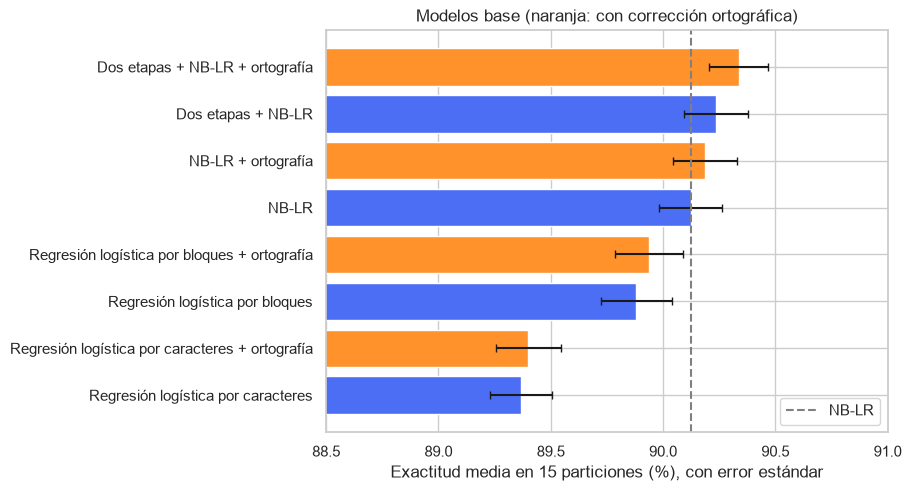

In [14]:
REFERENCIA = 'Dos etapas + NB-LR'
filas = []
for nombre, valores in ACC.items():
    vs_ref = comparar_pareado(valores, ACC[REFERENCIA])
    vs_nblr = comparar_pareado(valores, ACC['NB-LR'])
    filas.append({'Modelo': nombre, 'Exactitud media': valores.mean(), 'Desviación': valores.std(ddof=1),
                  'Dif. vs NB-LR (puntos)': vs_nblr['dif_puntos'], 'Gana a NB-LR en': vs_nblr['gana_en'],
                  'Dif. vs dos etapas + NB-LR (puntos)': vs_ref['dif_puntos'], 'Error estándar': vs_ref['error_estandar'], 'Gana a dos etapas en': vs_ref['gana_en']})
tabla_base = pd.DataFrame(filas).set_index('Modelo').sort_values('Exactitud media', ascending=False)
display(tabla_base.round(4))

print('Efecto de la corrección ortográfica en cada tipo de modelo (con corrección menos sin corrección, 15 particiones):')
filas = []
for tipo in TIPOS:
    c = comparar_pareado(ACC[tipo + SUFIJO], ACC[tipo])
    filas.append({'Modelo': tipo, 'Sin corrección': ACC[tipo].mean(), 'Con corrección': ACC[tipo + SUFIJO].mean(),
                  'Diferencia (puntos)': c['dif_puntos'], 'Error estándar': c['error_estandar'], 'Gana en (de 15)': c['gana_en'], 'Empata en': c['empata_en']})
tabla_orto = pd.DataFrame(filas).set_index('Modelo')
display(tabla_orto.round(4))

fig, ax = plt.subplots(figsize=(9, 4.8), constrained_layout=True)
orden = tabla_base['Exactitud media'].sort_values().index
colores = ['#FF922B' if SUFIJO in n else '#4C6EF5' for n in orden]
ax.barh(orden, [100 * ACC[n].mean() for n in orden], xerr=[100 * ACC[n].std(ddof=1) / np.sqrt(15) for n in orden], color=colores, capsize=3)
ax.axvline(100 * ACC['NB-LR'].mean(), color='gray', linestyle='--', label='NB-LR')
ax.set(xlim=(88.5, 91), xlabel='Exactitud media en 15 particiones (%), con error estándar', title='Modelos base (naranja: con corrección ortográfica)')
ax.legend(loc='lower right')
plt.show()

**La corrección ortográfica ayuda en los cuatro tipos de modelo, pero poco.** En las 15 particiones oficiales:

| Modelo | Sin corrección | Con corrección | Diferencia | Gana en |
|:---|:---:|:---:|:---:|:---:|
| NB-LR | 0,9012 | 0,9019 | +0,06 | 7 de 15 (3 empates) |
| Regresión logística por bloques | 0,8988 | 0,8994 | +0,06 | 9 de 15 |
| Regresión logística por caracteres | 0,8937 | 0,8940 | +0,03 | 8 de 15 |
| Dos etapas + NB-LR | 0,9024 | 0,9034 | +0,10 | 9 de 15 (3 empates) |

Las cuatro diferencias son positivas, pero cada una es de entre 0,7 y 2,3 errores estándar y ninguna gana en las 12 particiones que pide el criterio del proyecto. Es **menos que en las particiones de ajuste** (+0,12 para NB-LR), lo normal cuando se elige una configuración con unos datos y se mide con otros, y muy por debajo de la cota de +0,26 puntos que estimó la Mejora 10 (el corrector arregla una parte de las palabras raras, pero no las que son de contexto). Como evidencia combinada, el corrector da una mejora real pero **de entre 0,03 y 0,10 puntos**, es decir, de 1 a 3 reseñas de cada 3.000.

**Los modelos base.** El orden de la tabla es el esperado: el modelo en dos etapas con corrección (0,9034) es el mejor, seguido del mismo modelo sin corrección (0,9024), NB-LR (0,9012 sin y 0,9019 con corrección), la regresión por bloques (0,8988) y, lejos, la regresión por caracteres (0,8937). La regresión por caracteres es la más débil (0,75 puntos bajo NB-LR), pero la más distinta (sus errores coinciden entre el 66% y el 76% con los de los otros modelos).

## 7. Ensambles

### 7.1 Votación suave

La votación suave promedia las probabilidades de varios modelos. Como todos los modelos ya tienen sus probabilidades en las 15 particiones, cada combinación se evalúa sin reentrenar (el resultado es el mismo que el de un `VotingClassifier`). Se prueban estas combinaciones, fijadas **de antemano** (no se exploran todos los subconjuntos posibles, para no elegir por casualidad la mejor de muchas):

| Combinación | Idea |
|:---|:---|
| Votación de la Mejora 8 | Regresión logística por bloques + dos etapas: el ensamble que ya teníamos |
| Dos etapas con y sin corrección | Solo mide cuánto ayuda promediar el mismo modelo con y sin corrección |
| NB-LR y dos etapas con corrección | Los dos mejores modelos, corregidos |
| 3 modelos con corrección | NB-LR, regresión por bloques y dos etapas, corregidos |
| 4 modelos sin corrección | Los cuatro tipos de modelo, sin corrector |
| 4 modelos con corrección | Los cuatro tipos de modelo, con corrector |
| 8 modelos | Todos |

### 7.2 Apilamiento

El apilamiento (`StackingClassifier`) entrena una regresión logística que aprende cómo combinar las probabilidades de los 4 modelos con corrección. Para evaluarlo sin trampa, cada una de las 15 particiones reentrena todo el apilamiento solo con su parte de entrenamiento (con una validación cruzada interna de 3 particiones para generar las probabilidades con las que aprende el meta-modelo), y se evalúa con su parte de prueba.

In [15]:
CANDIDATOS_VOTO = {
    'Votación Mejora 8 (por bloques + dos etapas)': ['Regresión logística por bloques', 'Dos etapas + NB-LR'],
    'Dos etapas con y sin corrección': ['Dos etapas + NB-LR', 'Dos etapas + NB-LR' + SUFIJO],
    'NB-LR y dos etapas con corrección': ['NB-LR' + SUFIJO, 'Dos etapas + NB-LR' + SUFIJO],
    '3 modelos con corrección': ['NB-LR' + SUFIJO, 'Regresión logística por bloques' + SUFIJO, 'Dos etapas + NB-LR' + SUFIJO],
    '4 modelos sin corrección': SIN_ORTOGRAFIA,
    '4 modelos con corrección': CON_ORTOGRAFIA,
    '8 modelos': SIN_ORTOGRAFIA + CON_ORTOGRAFIA,
}


def probabilidades_voto(nombres):
    return [np.mean([PROB[n][i] for n in nombres], axis=0) for i in range(len(PART_OFICIALES))]


PROB_ENSAMBLE = {f'Voto: {nombre}': probabilidades_voto(nombres) for nombre, nombres in CANDIDATOS_VOTO.items()}
print('Votaciones calculadas:', len(PROB_ENSAMBLE))

Votaciones calculadas: 7


In [16]:
def apilamiento(estimadores):
    return StackingClassifier([(f'm{i}', clone(BASE[n])) for i, n in enumerate(estimadores)],
                              final_estimator=LogisticRegression(C=1, max_iter=3000), cv=3, stack_method='predict_proba', n_jobs=1)


inicio = time.time()
pila = apilamiento(CON_ORTOGRAFIA)
resultados_pila = Parallel(n_jobs=N_PROCESOS)(
    delayed(ajustar_y_predecir)(pila, X.iloc[p['ent']], y.iloc[p['ent']], X.iloc[p['prueba']]) for p in PART_OFICIALES)
PROB_ENSAMBLE['Apilamiento: 4 modelos con corrección'] = resultados_pila
print(f'Apilamiento en 15 particiones: {(time.time() - inicio) / 60:.1f} minutos')

Apilamiento en 15 particiones: 20.0 minutos


In [17]:
for nombre, P in PROB_ENSAMBLE.items():
    ACC[nombre] = exactitudes(P)

indices_seleccion = [i for i, p in enumerate(PART_OFICIALES) if p['semilla'] in SEMILLAS_OFICIALES[:2]]      # semillas 1 y 2 (10 particiones)
indices_confirmacion = [i for i, p in enumerate(PART_OFICIALES) if p['semilla'] == SEMILLAS_OFICIALES[2]]    # semilla 3 (5 particiones)

filas = []
for nombre in PROB_ENSAMBLE:
    v = ACC[nombre]
    vs_ref = comparar_pareado(v, ACC[REFERENCIA])
    vs_nblr = comparar_pareado(v, ACC['NB-LR'])
    filas.append({'Ensamble': nombre, 'Semillas 1 y 2 (10)': v[indices_seleccion].mean(), 'Semilla 3 (5)': v[indices_confirmacion].mean(), 'Exactitud 15': v.mean(),
                  'Dif. vs dos etapas (puntos)': vs_ref['dif_puntos'], 'Error estándar': vs_ref['error_estandar'], 'Gana a dos etapas en': vs_ref['gana_en'],
                  'Dif. vs NB-LR (puntos)': vs_nblr['dif_puntos'], 'Gana a NB-LR en': vs_nblr['gana_en']})
tabla_ens = pd.DataFrame(filas).set_index('Ensamble').sort_values('Semillas 1 y 2 (10)', ascending=False)
filas_ref = [{'Ensamble': f'(referencia) {n}', 'Semillas 1 y 2 (10)': ACC[n][indices_seleccion].mean(), 'Semilla 3 (5)': ACC[n][indices_confirmacion].mean(), 'Exactitud 15': ACC[n].mean()}
             for n in ['Dos etapas + NB-LR', 'NB-LR']]
display(pd.concat([tabla_ens, pd.DataFrame(filas_ref).set_index('Ensamble')]).round(4))

,Semillas 1 y 2 (10),Semilla 3 (5),Exactitud 15,Dif. vs dos etapas (puntos),Error estándar,Gana a dos etapas en,Dif. vs NB-LR (puntos),Gana a NB-LR en
Ensamble,,,,,,,,
Voto: 3 modelos con corrección,0.9035,0.9034,0.9035,0.1111,0.0890,10.0,0.2250,11.0
Voto: 4 modelos con corrección,0.9034,0.9020,0.9029,0.0583,0.0977,8.0,0.1722,9.0
Voto: NB-LR y dos etapas con corrección,0.9033,0.9043,0.9036,0.1278,0.0520,12.0,0.2417,13.0
Voto: Dos etapas con y sin corrección,0.9033,0.9038,0.9035,0.1111,0.0314,10.0,0.2250,10.0
Voto: 8 modelos,0.9029,0.9023,0.9027,0.0306,0.0909,8.0,0.1444,8.0
Voto: 4 modelos sin corrección,0.9023,0.9022,0.9023,-0.0056,0.0950,8.0,0.1083,8.0
Apilamiento: 4 modelos con corrección,0.9023,0.9038,0.9028,0.0417,0.1036,8.0,0.1556,9.0
Voto: Votación Mejora 8 (por bloques + dos etapas),0.9020,0.9028,0.9023,-0.0083,0.0924,5.0,0.1056,8.0
(referencia) Dos etapas + NB-LR,0.9021,0.9028,0.9024,NaN,NaN,NaN,NaN,NaN


In [18]:
# Regla fijada de antemano: se elige el ensamble con mayor exactitud en las semillas 1 y 2; la semilla 3 queda como confirmación.
elegido = tabla_ens.index[0]
print('Ensamble elegido con las semillas 1 y 2:', elegido)
print(f'  semillas 1 y 2: {ACC[elegido][indices_seleccion].mean():.4f} | semilla 3 (confirmación): {ACC[elegido][indices_confirmacion].mean():.4f} | '
      f'dos etapas + NB-LR en la semilla 3: {ACC[REFERENCIA][indices_confirmacion].mean():.4f}')

filas = []
for rival in ['NB-LR', 'Dos etapas + NB-LR', 'Dos etapas + NB-LR' + SUFIJO, 'Voto: Votación Mejora 8 (por bloques + dos etapas)']:
    for etiqueta, idx in [('15 particiones', slice(None)), ('solo semilla 3', indices_confirmacion)]:
        c = comparar_pareado(ACC[elegido][idx], ACC[rival][idx])
        filas.append({'Rival': rival, 'Particiones': etiqueta, 'Diferencia (puntos)': c['dif_puntos'], 'Error estándar': c['error_estandar'],
                      'Gana en': f'{c["gana_en"]} de {c["n"]}', 'Empata en': c['empata_en']})
tabla_elegido = pd.DataFrame(filas).set_index(['Rival', 'Particiones'])
display(tabla_elegido.round(3))

c = comparar_pareado(ACC[elegido], ACC[REFERENCIA])
cumple = c['gana_en'] >= 12 and c['dif_puntos'] > 2 * c['error_estandar']
print(f'Criterio del proyecto frente a dos etapas + NB-LR (gana en al menos 12 de 15 y diferencia mayor a 2 errores estándar): '
      f'gana en {c["gana_en"]} de 15, diferencia {c["dif_puntos"]:+.3f} puntos con error estándar {c["error_estandar"]:.3f} -> {"SÍ" if cumple else "NO"} cumple')

Ensamble elegido con las semillas 1 y 2: Voto: 3 modelos con corrección
  semillas 1 y 2: 0.9035 | semilla 3 (confirmación): 0.9034 | dos etapas + NB-LR en la semilla 3: 0.9028


Diferencia (puntos)  Error estándar   Gana en  Empata en
Rival                                              Particiones                                                             
NB-LR                                              15 particiones                0.225           0.093  11 de 15          0
                                                   solo semilla 3               -0.000           0.122    2 de 5          0
Dos etapas + NB-LR                                 15 particiones                0.111           0.089  10 de 15          0
                                                   solo semilla 3                0.058           0.060    4 de 5          0
Dos etapas + NB-LR + ortografía                    15 particiones                0.011           0.080   8 de 15          0
                                                   solo semilla 3               -0.008           0.050    3 de 5          0
Voto: Votación Mejora 8 (por bloques + dos etapas) 15 particiones                0.119           0.053  11 de 15          1
                                                   solo semilla 3                0.058           0.094    3 de 5          0

Criterio del proyecto frente a dos etapas + NB-LR (gana en al menos 12 de 15 y diferencia mayor a 2 errores estándar): gana en 10 de 15, diferencia +0.111 puntos con error estándar 0.089 -> NO cumple


### 7.3 ¿Cuánto del resultado puede ser suerte? Corrección por comparaciones múltiples

En la tabla anterior se comparan 8 ensambles contra el mismo modelo de referencia. Cuando se miran varios candidatos, es normal que alguno parezca "significativo" por azar, aunque ninguno sea mejor que la referencia. Para medirlo se usa una **prueba de permutación de signos con corrección por el máximo**: bajo la hipótesis de que ningún ensamble difiere de la referencia, la diferencia en cada partición es igual de probable de ser positiva o negativa. Se cambian al azar los signos de las diferencias de las 15 particiones (los mismos cambios para todos los candidatos, 20.000 veces) y se registra en cada repetición el mayor estadístico t entre los 8 candidatos. El **valor p ajustado** de un candidato es la proporción de repeticiones en que ese máximo supera lo que él obtuvo. El valor p sin ajustar mira solo a ese candidato.

**Una advertencia importante:** las 15 particiones comparten reseñas de entrenamiento, así que no son independientes y el error estándar usual (el que se usa en todo el notebook) es demasiado optimista. La corrección de Nadeau y Bengio (2003), la habitual para validación cruzada repetida, calcula la varianza de la diferencia media con el factor `1/J + n_prueba/n_entrenamiento` en lugar de `1/J` (J = 15 particiones, 2.400 reseñas de prueba y 9.600 de entrenamiento), lo que multiplica el error estándar por 2,2 y reduce cada estadístico t por ese mismo factor. Se muestran los dos: el t de la prueba de permutación y el t corregido (con su valor p de una cola y con la corrección de Bonferroni para los 8 candidatos).

In [19]:
candidatos = list(PROB_ENSAMBLE)
D = np.array([ACC[n] - ACC[REFERENCIA] for n in candidatos])                    # (candidatos, 15 particiones)


def estadistico_t(D_):
    return D_.mean(axis=1) / (D_.std(axis=1, ddof=1) / np.sqrt(D_.shape[1]))


t_obs = estadistico_t(D)
J = D.shape[1]
factor_nb = np.sqrt((1 / J) / (1 / J + len(PART_OFICIALES[0]['prueba']) / len(PART_OFICIALES[0]['ent'])))      # Nadeau y Bengio
t_corregido = t_obs * factor_nb
p_corregido = stats.t.sf(t_corregido, df=J - 1)
generador = np.random.default_rng(RANDOM_STATE)
signos = generador.choice([-1, 1], size=(20000, D.shape[1]))
t_nulo = np.array([estadistico_t(D * s) for s in signos])                       # (20000, candidatos)
t_nulo_maximo = t_nulo.max(axis=1)

tabla_maxt = pd.DataFrame({'Diferencia vs dos etapas (puntos)': 100 * D.mean(axis=1), 'Estadístico t': t_obs,
                           'p sin ajustar': [(t_nulo[:, j] >= t_obs[j]).mean() for j in range(len(candidatos))],
                           'p ajustado (8 candidatos)': [(t_nulo_maximo >= t).mean() for t in t_obs],
                           'Estadístico t corregido': t_corregido, 'p (t corregido, una cola)': p_corregido,
                           'p corregido con Bonferroni (8)': np.minimum(1, len(candidatos) * p_corregido)}, index=candidatos).sort_values('Estadístico t', ascending=False)
display(tabla_maxt.round(3))
print(f'Mejor candidato por t: {tabla_maxt.index[0]} (t = {tabla_maxt["Estadístico t"].iloc[0]:.2f}) | el ensamble elegido por la regla es: {elegido}')
print(f'Si ninguno fuera mejor que la referencia, el mayor t de los 8 candidatos pasaría de {tabla_maxt["Estadístico t"].iloc[0]:.2f} en el '
      f'{100 * (t_nulo_maximo >= tabla_maxt["Estadístico t"].iloc[0]).mean():.0f}% de las veces.')
print(f'Factor de Nadeau y Bengio sobre el estadístico t: {factor_nb:.3f} (el error estándar se multiplica por {1 / factor_nb:.2f}). '
      f'Con él, el t del mejor candidato baja de {tabla_maxt["Estadístico t"].iloc[0]:.2f} a {tabla_maxt["Estadístico t corregido"].iloc[0]:.2f}.')

,Diferencia vs dos etapas (puntos),Estadístico t,p sin ajustar,p ajustado (8 candidatos),Estadístico t corregido,"p (t corregido, una cola)",p corregido con Bonferroni (8)
Voto: Dos etapas con y sin corrección,0.111,3.538,0.002,0.009,1.623,0.063,0.507
Voto: NB-LR y dos etapas con corrección,0.128,2.458,0.011,0.067,1.128,0.139,1.000
Voto: 3 modelos con corrección,0.111,1.249,0.117,0.364,0.573,0.288,1.000
Voto: 4 modelos con corrección,0.058,0.597,0.287,0.647,0.274,0.394,1.000
Apilamiento: 4 modelos con corrección,0.042,0.402,0.337,0.720,0.185,0.428,1.000
Voto: 8 modelos,0.031,0.336,0.370,0.754,0.154,0.440,1.000
Voto: 4 modelos sin corrección,-0.006,-0.058,0.521,0.877,-0.027,0.511,1.000
Voto: Votación Mejora 8 (por bloques + dos etapas),-0.008,-0.090,0.524,0.884,-0.041,0.516,1.000


Mejor candidato por t: Voto: Dos etapas con y sin corrección (t = 3.54) | el ensamble elegido por la regla es: Voto: 3 modelos con corrección
Si ninguno fuera mejor que la referencia, el mayor t de los 8 candidatos pasaría de 3.54 en el 1% de las veces.
Factor de Nadeau y Bengio sobre el estadístico t: 0.459 (el error estándar se multiplica por 2.18). Con él, el t del mejor candidato baja de 3.54 a 1.62.


**Ningún ensamble mejora de forma clara al mejor modelo.** La regla fijada de antemano elige el ensamble con mayor exactitud en las semillas 1 y 2: la **votación de 3 modelos con corrección** (NB-LR, regresión por bloques y dos etapas, los tres corregidos), con 0,9035 en esas 10 particiones y 0,9034 en las 5 de la semilla 3 (donde dos etapas + NB-LR obtiene 0,9028). En las 15 particiones queda en 0,9035, es decir, **+0,11 puntos sobre dos etapas + NB-LR (0,9024) y +0,23 sobre NB-LR (0,9012)**, pero con error estándar de 0,09 puntos, ganando en 10 de 15 particiones (el criterio pide 12 de 15 y una diferencia de más de 2 errores estándar): **no cumple el criterio**.

Otras lecturas de la tabla:

- **El ensamble que ya teníamos (votación de la Mejora 8: regresión por bloques + dos etapas) queda en 0,9023**, igual que dos etapas + NB-LR solo (0,9024): en estas 15 particiones, ese ensamble no mejoraba al mejor modelo. Cambiar la regresión por bloques por NB-LR y agregar la corrección sube la votación a 0,9035.
- **El ensamble "NB-LR y dos etapas con corrección" sí cumple el criterio** (0,9036; +0,13 puntos con error estándar de 0,05; gana en 12 de 15), pero **no fue el elegido por la regla** (en las semillas 1 y 2 quedó 0,0002 por debajo del elegido) y es el mejor de 8 candidatos comparados, así que no se puede presentar como un hallazgo (ver el párrafo siguiente). Elegirlo ahora, después de ver las 15 particiones, sería escoger a posteriori.
- **El apilamiento no mejora a la votación** (0,9028, gana en 8 de 15): con 4 modelos casi iguales y un meta-modelo que debe aprender sus pesos con solo 9.600 reseñas, promediar sin aprender nada es igual de bueno o mejor. Es el resultado de la Mejora 8, que también encontró que el apilamiento solo igualaba a la regresión logística.
- **Agregar más modelos no ayuda.** Las votaciones con 4 modelos (0,9029) y con 8 (0,9027) quedan por debajo de la de 3 (0,9035): la regresión por caracteres, que es la más distinta, es también la más débil y empeora el promedio.

**¿Cuánto de esto puede ser suerte?** La prueba de permutación de la sección 7.3 compara los 8 ensambles con dos etapas + NB-LR teniendo en cuenta que se miraron 8 candidatos. El de mayor estadístico es "dos etapas con y sin corrección" (+0,11 puntos, t = 3,5, p ajustado de 0,009), que a primera vista parece significativo. Pero es casi el mismo modelo dos veces (sus errores coinciden en el 96% al 97%), así que sus diferencias con la referencia son pequeñas pero muy parejas y el error estándar usual sale diminuto, y ese error estándar ignora que las 15 particiones comparten reseñas de entrenamiento. Con la corrección de Nadeau y Bengio (que multiplica el error estándar por 2,18) su t baja a **1,62** (p de una cola de 0,06, y de 0,51 con la corrección de Bonferroni para 8 candidatos). El ensamble elegido por la regla queda con t corregido de 0,57 (p = 0,29) y el único que cumplía el criterio de las 12 de 15 con 1,13 (p = 0,14). **Ninguno de los 8 ensambles se distingue de forma demostrable de dos etapas + NB-LR**: los datos son compatibles con una mejora real de alrededor de +0,1 puntos, pero también con cero.

## 8. Diversidad y dónde se gana

Un ensamble solo gana si sus modelos se equivocan en reseñas distintas. Se mide cuánto se parecen los errores de los modelos base (con las predicciones de la primera repetición, que cubren cada reseña una vez) y se separa la ganancia del ensamble entre los dos tipos de reseñas que identificó la Mejora 10: las de **cierre de duda** (la etiqueta es azar respecto del texto) y **todas las demás**.

In [20]:
def acierta_por_resena(nombre_probabilidades, semilla):
    """Vector de 12.000 aciertos (0/1): para cada reseña, si el modelo acertó cuando estuvo en la parte de prueba (una vez por semilla)."""
    acierta = np.zeros(len(y_arr))
    for i, p in enumerate(PART_OFICIALES):
        if p['semilla'] == semilla:
            acierta[p['prueba']] = a_etiquetas(nombre_probabilidades[i]) == Y_PRUEBA[i]
    return acierta


todas_las_probabilidades = {**PROB, **PROB_ENSAMBLE}
semilla1 = SEMILLAS_OFICIALES[0]
errores = {n: 1 - acierta_por_resena(PROB[n], semilla1) for n in BASE}
nombres = list(BASE)
matriz = pd.DataFrame({b: {a: (errores[a] * errores[b]).sum() / errores[a].sum() for a in nombres} for b in nombres})
print('Errores en la semilla 1 (de 12.000 reseñas):', {n: int(e.sum()) for n, e in errores.items()})
print('% de los errores de la fila que también comete la columna:')
display(matriz.round(2))

Errores en la semilla 1 (de 12.000 reseñas): {'NB-LR': 1215, 'NB-LR + ortografía': 1199, 'Regresión logística por bloques': 1205, 'Regresión logística por bloques + ortografía': 1186, 'Regresión logística por caracteres': 1270, 'Regresión logística por caracteres + ortografía': 1271, 'Dos etapas + NB-LR': 1184, 'Dos etapas + NB-LR + ortografía': 1163}
% de los errores de la fila que también comete la columna:


,NB-LR,NB-LR + ortografía,Regresión logística por bloques,Regresión logística por bloques + ortografía,Regresión logística por caracteres,Regresión logística por caracteres + ortografía,Dos etapas + NB-LR,Dos etapas + NB-LR + ortografía
NB-LR,1.00,0.97,0.74,0.72,0.73,0.73,0.84,0.83
NB-LR + ortografía,0.98,1.00,0.73,0.72,0.74,0.74,0.84,0.84
Regresión logística por bloques,0.74,0.73,1.00,0.94,0.71,0.71,0.81,0.80
Regresión logística por bloques + ortografía,0.73,0.73,0.95,1.00,0.71,0.71,0.80,0.81
Regresión logística por caracteres,0.70,0.70,0.68,0.66,1.00,0.97,0.70,0.70
Regresión logística por caracteres + ortografía,0.70,0.69,0.67,0.66,0.97,1.00,0.69,0.69
Dos etapas + NB-LR,0.86,0.85,0.82,0.80,0.75,0.74,1.00,0.96
Dos etapas + NB-LR + ortografía,0.87,0.87,0.83,0.82,0.76,0.76,0.97,1.00


In [21]:
# Grupos de la Mejora 10: reseñas con cierre de duda (la etiqueta es azar respecto del texto) y el resto
def normalizar(texto):
    texto = unicodedata.normalize('NFKD', texto.lower()).encode('ascii', 'ignore').decode()
    return re.sub(r'\s+', ' ', re.sub(r'[^\w\s]', ' ', texto)).strip()


ultima_oracion = [normalizar(separar_oraciones(t)[-1]) for t in train['text']]
frecuencia_ultima = Counter(ultima_oracion)
CIERRE_NEUTRO = re.compile(r'\bnada mas que (agregar|comentar|contar)\b')
FORMULAS_DUDA = re.compile(r'\b(sigo con (la )?dudas?|ando con dudas|en la duda|misma duda|sin decidirme|no me decido|no he decidido|'
                           r'sentimientos encontrados|a (tu )?criterio|cada quien|juzgue\w*|para gustos|ni fu|ni lo mejor|ni lo peor|'
                           r'ni tan bueno|que recomendar|sus conclusiones|sopes\w*|hay de todo|queda mi valoracion|ahi queda)\b')
es_cierre_duda = np.array([(not CIERRE_NEUTRO.search(u)) and (frecuencia_ultima[u] >= 10 or bool(FORMULAS_DUDA.search(u)) or
                                                             ('ahi lo dejo' in u and len(u.split()) <= 5)) for u in ultima_oracion])
print(f'Reseñas con cierre de duda: {es_cierre_duda.sum()} ({100 * es_cierre_duda.mean():.1f}%)')

comparados = ['NB-LR', 'NB-LR' + SUFIJO, 'Dos etapas + NB-LR', 'Dos etapas + NB-LR' + SUFIJO, elegido]
filas = []
for nombre in comparados:
    acierta = np.mean([acierta_por_resena(todas_las_probabilidades[nombre], s) for s in SEMILLAS_OFICIALES], axis=0)      # promedio de las 3 repeticiones
    filas.append({'Modelo': nombre, 'Exactitud total': acierta.mean(),
                  'Exactitud con cierre de duda': acierta[es_cierre_duda].mean(), 'Exactitud en el resto': acierta[~es_cierre_duda].mean(),
                  'Errores con cierre de duda (de 12.000)': (1 - acierta[es_cierre_duda]).sum(), 'Errores en el resto (de 12.000)': (1 - acierta[~es_cierre_duda]).sum()})
tabla_grupos = pd.DataFrame(filas).set_index('Modelo')
display(tabla_grupos.round(4))

Reseñas con cierre de duda: 1456 (12.1%)


,Exactitud total,Exactitud con cierre de duda,Exactitud en el resto,Errores con cierre de duda (de 12.000),Errores en el resto (de 12.000)
Modelo,,,,,
NB-LR,0.9012,0.5337,0.9520,679.0000,506.3333
NB-LR + ortografía,0.9019,0.5318,0.9530,681.6667,496.0000
Dos etapas + NB-LR,0.9024,0.5234,0.9547,694.0000,477.6667
Dos etapas + NB-LR + ortografía,0.9034,0.5240,0.9557,693.0000,466.6667
Voto: 3 modelos con corrección,0.9035,0.5227,0.9561,695.0000,463.3333


**Diversidad.** Los errores de los modelos base se parecen mucho entre sí. El modelo en dos etapas comparte el 80% al 87% de sus errores con NB-LR y con la regresión por bloques; entre NB-LR y la regresión por bloques el 72% a 74%. La regresión por caracteres es la más distinta (entre 66% y 76%), pero no lo suficiente como para compensar que se equivoca más. La corrección ortográfica casi no cambia el reparto: un modelo con y sin corrección comparte el 94% al 98% de sus errores. Por eso un ensamble solo puede corregir unas pocas reseñas.

**Dónde se gana.** Todo el efecto está **fuera del cierre de duda**. Pasando de NB-LR al ensamble elegido, los errores del resto de las reseñas bajan de 506 a 463 por cada 12.000 (una ganancia de 0,36 puntos de exactitud total, de 0,9520 a 0,9561 de exactitud en ese grupo), mientras que en el cierre de duda los errores suben un poco (679 frente a 695, es decir, 0,13 puntos menos; la exactitud va de 0,534 a 0,523, que es ruido de una moneda al aire). El neto es la diferencia de 0,23 puntos que se vio en la sección 7. Esto coincide con la Mejora 10: el cierre de duda aporta cerca de 5,8 puntos de error que ningún modelo basado en el texto puede quitar, y lo que se puede ganar está en el resto, donde el ensamble corrige cerca del 8,5% de los errores.

## 9. Modelo final y predicciones para la competencia

Se entrena el ensamble elegido con las 12.000 reseñas etiquetadas, sin volver a buscar hiperparámetros, y con él se predicen las reseñas de `eval.csv`. Como el resultado de la sección 7 dice si el ensamble cumple o no el criterio del proyecto frente a dos etapas + NB-LR, el envío se genera de todos modos (para poder medir su puntaje público), pero la recomendación para Kaggle depende de ese resultado (ver las conclusiones).

In [22]:
NOMBRE_MODELO = 'ensamble_ortografia'

nombre_ensamble = elegido.split(': ', 1)[1]
if elegido.startswith('Voto'):
    miembros = CANDIDATOS_VOTO[nombre_ensamble]
    modelo_final = VotingClassifier([(f'm{i}', clone(BASE[n])) for i, n in enumerate(miembros)], voting='soft')
else:
    miembros = CON_ORTOGRAFIA
    modelo_final = apilamiento(miembros)
print('Ensamble final:', elegido, '| modelos:', miembros)

inicio = time.time()
modelo_final.fit(X, y)       # las 12.000 reseñas etiquetadas (en serie: un modelo entrenado en procesos paralelos no se puede guardar con joblib.dump)
print(f'Entrenado con las 12.000 reseñas en {(time.time() - inicio) / 60:.1f} minutos')

pred_eval = modelo_final.predict(evaluacion[['text']])
envio = pd.DataFrame({'id': evaluacion['id'], 'answer': pred_eval})
envio.to_csv(os.path.join(RUTA_ENVIOS, f'submission_{NOMBRE_MODELO}.csv'), index=False)
print('Archivo:', f'submission_{NOMBRE_MODELO}.csv', '|', envio.shape)
print('Mismas columnas y mismos ids que sample_submission:',
      list(envio.columns) == list(muestra_envio.columns) and (envio['id'] == muestra_envio['id']).all())

for archivo in ['submission_dos_etapas_nblr.csv', 'submission_votacion_suave_mejores.csv', 'submission_knn_compuerta_tres_regresiones.csv',
                'submission_nb_regresion_logistica.csv', 'submission_regresion_logistica_ajuste_fino.csv']:
    ruta = os.path.join(RUTA_ENVIOS, archivo)
    if os.path.exists(ruta):
        print(f'Predicciones distintas respecto a {archivo}: {(envio["answer"] != pd.read_csv(ruta)["answer"]).sum()} de {len(envio)}')
display(pd.DataFrame({'train (real)': train['label'].value_counts(normalize=True),
                      'eval (predicho)': envio['answer'].value_counts(normalize=True)}).reindex(ORDEN_CLASES).round(3))

Ensamble final: Voto: 3 modelos con corrección | modelos: ['NB-LR + ortografía', 'Regresión logística por bloques + ortografía', 'Dos etapas + NB-LR + ortografía']


Entrenado con las 12.000 reseñas en 4.0 minutos


Archivo: submission_ensamble_ortografia.csv | (3000, 2)
Mismas columnas y mismos ids que sample_submission: True
Predicciones distintas respecto a submission_dos_etapas_nblr.csv: 51 de 3000
Predicciones distintas respecto a submission_votacion_suave_mejores.csv: 42 de 3000
Predicciones distintas respecto a submission_knn_compuerta_tres_regresiones.csv: 99 de 3000
Predicciones distintas respecto a submission_nb_regresion_logistica.csv: 95 de 3000
Predicciones distintas respecto a submission_regresion_logistica_ajuste_fino.csv: 97 de 3000


,train (real),eval (predicho)
negativo,0.351,0.356
neutral,0.298,0.279
positivo,0.351,0.365


In [23]:
ruta_modelo = os.path.join(RUTA_MODELOS, f'{NOMBRE_MODELO}.joblib')
joblib.dump(modelo_final, ruta_modelo)
modelo_cargado = joblib.load(ruta_modelo)
print('El modelo guardado reproduce exactamente las mismas predicciones:', (modelo_cargado.predict(evaluacion[['text']]) == pred_eval).all())
print(f'Tamaño del archivo del modelo: {os.path.getsize(ruta_modelo) / 1e6:.0f} MB')
print(f'Tiempo total de ejecución del notebook: {(time.time() - INICIO_NOTEBOOK) / 60:.1f} minutos')

El modelo guardado reproduce exactamente las mismas predicciones: True
Tamaño del archivo del modelo: 22 MB
Tiempo total de ejecución del notebook: 38.7 minutos


El ensamble elegido por la regla (votación suave de NB-LR, regresión por bloques y dos etapas, los tres con corrección ortográfica) se entrenó con las 12.000 reseñas. Su envío (`submission_ensamble_ortografia.csv`) cambia 51 de las 3.000 predicciones respecto al de dos etapas + NB-LR (el de mejor puntaje público, 0,9077), 42 respecto a la votación suave de la Mejora 8 y entre 95 y 99 respecto a los envíos de NB-LR y de la compuerta KNN. La distribución de clases predicha (35,6% negativas, 27,9% neutrales y 36,5% positivas) es parecida a la de entrenamiento, con algo menos de neutrales, como en los demás envíos.

**Sobre este envío.** Como el ensamble no cumple el criterio del proyecto, no hay una razón para considerarlo mejor que el envío de dos etapas + NB-LR; la diferencia esperada es de 1 a 3 reseñas de cada 3.000, mucho menos que el ruido del puntaje público. Se genera para poder medir su puntaje público y porque es el mejor de los modelos medidos, no porque se haya demostrado que gane. El archivo del modelo (`models/ensamble_ortografia.joblib`) pesa unos 22 MB, porque guarda tres modelos entrenados, entre ellos el de dos etapas.

## 10. Conclusiones

- **La corrección ortográfica ayuda, pero muy poco.** Mejora los cuatro tipos de modelo en las 15 particiones oficiales, entre +0,03 y +0,10 puntos (1 a 3 reseñas de cada 3.000), y ninguna de las cuatro diferencias cumple por sí sola el criterio del proyecto (12 de 15 particiones). En las particiones de ajuste daba +0,12 para NB-LR; la cifra oficial para NB-LR es +0,06. Está por debajo de la cota de +0,26 que estimó la Mejora 10, porque corrige los errores de ortografía de palabras que el modelo ya conocía pero no los que se dan en palabras de contexto. El corrector es barato (añade cerca de un segundo por ajuste), solo usa el vocabulario de entrenamiento y en las 15 particiones no se observó ningún daño, así que es razonable dejarlo.
- **El ensamble no mejora de forma demostrable al mejor modelo.** La votación de 3 modelos con corrección, elegida por la regla fijada de antemano, obtiene 0,9035 frente a 0,9024 de dos etapas + NB-LR (+0,11 puntos, error estándar 0,09, 10 de 15 particiones): no cumple el criterio. El único ensamble que sí lo cumple ("NB-LR y dos etapas con corrección") no fue el elegido y es el mejor de 8 candidatos, por lo que su ventaja puede ser suerte (con la corrección de Nadeau y Bengio y por comparaciones múltiples de la sección 7.3, su t baja de 2,46 a 1,13). El ensamble de la Mejora 8 no mejoraba al modelo en dos etapas en estas particiones (0,9023 frente a 0,9024), y el apilamiento (0,9028) no mejora a la votación.
- **Por qué casi no se gana.** Los modelos se equivocan en las mismas reseñas (el modelo en dos etapas comparte del 82% al 87% de sus errores con NB-LR y la regresión por bloques), y todas las ganancias están fuera del cierre de duda, donde el ensamble corrige cerca del 8,5% de los errores. En el cierre de duda no hay ninguna mejora: es azar.
- **Lo que se puede esperar.** Con la corrección y el ensamble el mejor modelo medido sube de 0,9024 a unos 0,9035 (+0,1 puntos), que es lo que la Mejora 10 anticipaba para este tipo de ideas ("unas décimas"). Para el ranking de Kaggle esa diferencia es mucho menor que el error del puntaje público (cerca de 1 punto con 900 reseñas) y que el del privado (0,65 puntos con 2.100).
- **Recomendación.** No hay evidencia para cambiar el modelo en dos etapas + NB-LR (0,9024), que sigue siendo una elección válida y más simple. Si se quiere incorporar la corrección ortográfica por su bajo costo, las opciones con mejor resultado medido son el modelo en dos etapas con corrección (0,9034) y la votación de 3 modelos con corrección (0,9035, la elegida por la regla); cualquiera de las dos está dentro del ruido de dos etapas + NB-LR, y la diferencia esperada es de 1 a 3 reseñas de cada 3.000.
- **Limitaciones.** Las 15 particiones comparten reseñas de entrenamiento, así que los errores estándar usuales (y la prueba de permutación) son optimistas; la corrección de Nadeau y Bengio de la sección 7.3 los multiplica por 2,2. El corrector tiene algunas correcciones dudosas en palabras legítimas poco frecuentes. La regresión por caracteres no se ajustó (`C = 10` fijo). Y la elección del ensamble se hizo con 8 candidatos fijados de antemano, no con una búsqueda amplia.

## 11. Uso de herramientas de IA generativa

**Declaración del uso.** Se utilizó Claude Code (modelo Claude Sonnet 5.5, de Anthropic) como apoyo para: proponer y generar un primer esqueleto del código de este notebook, depurar errores, ejecutar los experimentos y redactar las explicaciones.

**Prompts utilizados.**

1. Después de la Mejora 10 (diagnóstico del error y techo de exactitud), que estimó el máximo posible de las ideas pendientes, se pidió: *"implementa la corrección ortográfica y el ensamble"*. La herramienta propuso el corrector basado en el vocabulario de entrenamiento, probó varias versiones con particiones de ajuste distintas a las oficiales, y diseñó la evaluación del ensamble con las 15 particiones de las Mejoras 4 y 7.

**Análisis crítico del resultado.**

[Completar por el equipo: ¿qué partes del código y de las explicaciones generadas fueron correctas y útiles? ¿qué errores, imprecisiones o limitaciones se identificaron? ¿qué decisiones técnicas se cambiaron respecto a lo que propuso la herramienta y por qué? ¿qué conceptos del curso permitieron evaluar o corregir la respuesta?]

**Aportes propios del equipo.**

[Completar por el equipo: qué se desarrolló, modificó o decidió, qué ajustes se hicieron al código y a las explicaciones, y qué se aprendió del proceso.]

## 12. Cómo replicar los resultados

1. Crear un entorno con Python 3.9 e instalar las librerías con `pip install -r requirements.txt` (están en la raíz del proyecto). El notebook se ejecutó con Python 3.13.14, scikit-learn 1.8.0, numpy 2.5.2 y pandas 2.3.3.
2. Mantener la estructura de carpetas del proyecto: este notebook está en `notebooks/`, los datos en `data/`. El notebook se ejecuta desde la carpeta `notebooks/`.
3. Ejecutar todas las celdas en orden (`Restart & Run All`). Tarda aproximadamente 40 minutos con 8 procesos en paralelo (`N_PROCESOS`) en un computador de 16 núcleos y 32 GB de memoria; lo más lento son los 120 ajustes de las 15 particiones (el modelo en dos etapas, un minuto por ajuste) y el apilamiento anidado de la sección 7.2. Con menos memoria conviene bajar `N_PROCESOS`.
4. Al terminar se generan `models/ensamble_ortografia.joblib` y `submissions/submission_ensamble_ortografia.csv`.

Todas las fuentes de aleatoriedad usan semillas fijas, por lo que las cifras se reproducen con las mismas versiones de las librerías. Para cargar el modelo guardado fuera del notebook hay que ejecutar antes las celdas que definen las funciones y las clases (`NBRegresionLogistica`, `ModeloDosEtapasNBLR` y `CorregirOrtografia`, entre otras) usadas por el pipeline.